# **Step 1:- Data Cleaning & Preprocessing**

In [89]:
import pandas as pd
import numpy as np

In [90]:
# Load the dataset
file_path = "/content/resume_data.csv"
df = pd.read_csv(file_path)

In [91]:
# Display basic information before cleaning
print("Before Cleaning:")
print(df.info())



Before Cleaning:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9544 entries, 0 to 9543
Data columns (total 35 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   address                              784 non-null    object 
 1   career_objective                     4740 non-null   object 
 2   skills                               9488 non-null   object 
 3   educational_institution_name         9460 non-null   object 
 4   degree_names                         9460 non-null   object 
 5   passing_years                        9460 non-null   object 
 6   educational_results                  9460 non-null   object 
 7   result_types                         9460 non-null   object 
 8   major_field_of_studies               9460 non-null   object 
 9   professional_company_names           9460 non-null   object 
 10  company_urls                         9460 non-null   object 
 11  start_dates  

In [92]:
print("Missing Values per Column:")
print(df.isnull().sum())

Missing Values per Column:
address                                8760
career_objective                       4804
skills                                   56
educational_institution_name             84
degree_names                             84
passing_years                            84
educational_results                      84
result_types                             84
major_field_of_studies                   84
professional_company_names               84
company_urls                             84
start_dates                              84
end_dates                                84
related_skils_in_job                     84
positions                                84
locations                                84
responsibilities                          0
extra_curricular_activity_types        6118
extra_curricular_organization_names    6118
extra_curricular_organization_links    6118
role_positions                         6118
languages                              8844
profi

In [93]:
# Step 1: Remove Duplicates
df.drop_duplicates(inplace=True)

In [94]:
# Step 2: Drop Columns with Excessive Missing Values (Threshold: >50%)
missing_threshold = len(df) * 0.5
df = df.dropna(thresh=missing_threshold, axis=1)

In [95]:
# Step 3: Fill Missing Values for Important Columns
# Fill missing text data with 'Unknown'
text_columns = df.select_dtypes(include=['object']).columns
df[text_columns] = df[text_columns].fillna("Unknown")

In [96]:
# Fill missing numerical data with median
numeric_columns = df.select_dtypes(include=['number']).columns
df[numeric_columns] = df[numeric_columns].apply(lambda x: x.fillna(x.median()))

In [97]:
print(df.isnull().sum())

skills                          0
educational_institution_name    0
degree_names                    0
passing_years                   0
educational_results             0
result_types                    0
major_field_of_studies          0
professional_company_names      0
company_urls                    0
start_dates                     0
end_dates                       0
related_skils_in_job            0
positions                       0
locations                       0
responsibilities                0
﻿job_position_name              0
educationaL_requirements        0
experiencere_requirement        0
age_requirement                 0
responsibilities.1              0
skills_required                 0
matched_score                   0
dtype: int64


In [98]:
# Step 4: Standardize Text Columns (Convert to Lowercase & Strip Extra Spaces)
df[text_columns] = df[text_columns].apply(lambda x: x.str.lower().str.strip())

In [99]:
# Step 5: Save Cleaned Data
df.to_csv("/content/cleaned_resume_data.csv", index=False)

In [100]:
# Display basic information after cleaning
df=pd.read_csv("/content/cleaned_resume_data.csv")
print("After Cleaning:")
print(df.info())
print("Missing Values per Column After Cleaning:")
print(df.isnull().sum())

After Cleaning:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9544 entries, 0 to 9543
Data columns (total 22 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   skills                        9544 non-null   object 
 1   educational_institution_name  9544 non-null   object 
 2   degree_names                  9544 non-null   object 
 3   passing_years                 9544 non-null   object 
 4   educational_results           9544 non-null   object 
 5   result_types                  9544 non-null   object 
 6   major_field_of_studies        9544 non-null   object 
 7   professional_company_names    9544 non-null   object 
 8   company_urls                  9544 non-null   object 
 9   start_dates                   9544 non-null   object 
 10  end_dates                     9544 non-null   object 
 11  related_skils_in_job          9544 non-null   object 
 12  positions                     9544 non-null   

# **Step 2:- Skill Extraction & Categorization (NLP & Text Processing)**

In [101]:
import spacy
import re

In [102]:
# Load the dataset
file_path = "/content/cleaned_resume_data.csv"
df = pd.read_csv(file_path)

In [103]:
print(df.columns)


Index(['skills', 'educational_institution_name', 'degree_names',
       'passing_years', 'educational_results', 'result_types',
       'major_field_of_studies', 'professional_company_names', 'company_urls',
       'start_dates', 'end_dates', 'related_skils_in_job', 'positions',
       'locations', 'responsibilities', '﻿job_position_name',
       'educationaL_requirements', 'experiencere_requirement',
       'age_requirement', 'responsibilities.1', 'skills_required',
       'matched_score'],
      dtype='object')


In [104]:
# Load pre-trained spaCy model (use 'en_core_web_sm' or upgrade to 'en_core_web_md' for better results)
nlp = spacy.load("en_core_web_sm")

/usr/local/lib/python3.11/dist-packages/spacy/util.py:1740: UserWarning: [W111] Jupyter notebook detected: if using `prefer_gpu()` or `require_gpu()`, include it in the same cell right before `spacy.load()` to ensure that the model is loaded on the correct device. More information: http://spacy.io/usage/v3#jupyter-notebook-gpu
  warnings.warn(Warnings.W111)


In [105]:

# Predefined skill set for extraction (expand this list as needed)
skill_keywords = ["python", "sql", "machine learning", "power bi", "tableau", "nlp", "deep learning", "data analysis", "sharepoint", "excel", "power automate", "r", "aws", "azure", "java", "c++"]


In [106]:
# Function to extract skills from resume text
def extract_skills(text):
    text = text.lower()  # Convert text to lowercase
    extracted_skills = set()

    # Use NLP for named entity recognition (NER)
    doc = nlp(text)
    for token in doc:
        if token.text in skill_keywords:
            extracted_skills.add(token.text)

    # Use regex to capture additional skills
    for skill in skill_keywords:
        if re.search(rf'\b{skill}\b', text):
            extracted_skills.add(skill)

    return list(extracted_skills)

In [107]:
# Apply skill extraction on relevant columns
df["Extracted_Skills"] = df["skills"].astype(str).apply(extract_skills) + df["related_skils_in_job"].astype(str).apply(extract_skills)


In [108]:
# Save the extracted skills to a new file
df.to_csv("/content/resume_skills_extracted.csv", index=False)

In [109]:
# Display sample results
print(df[["skills", "related_skils_in_job", "Extracted_Skills"]].head())

                                              skills  \
0  ['big data', 'hadoop', 'hive', 'python', 'mapr...   
1  ['data analysis', 'data analytics', 'business ...   
2  ['software development', 'machine learning', '...   
3  ['accounts payables', 'accounts receivables', ...   
4  ['analytical reasoning', 'compliance testing k...   

                                related_skils_in_job  \
0                                     [['big data']]   
1  [['data analysis', 'business analysis', 'machi...   
2  [['unified payment interface', 'risk predictio...   
3  [['accounts receivables', 'banking', 'g/l acco...   
4  [['collections', 'accounts receivable', 'finan...   

                                    Extracted_Skills  
0       [java, azure, c++, python, machine learning]  
1  [r, tableau, machine learning, data analysis, ...  
2     [machine learning, c++, python, deep learning]  
3                                            [excel]  
4                                                 [

# **Step 3:- Resume Categorization Based on Extracted Skills**

In [110]:
# Load the dataset with extracted skills
file_path = "/content/resume_skills_extracted.csv"
df = pd.read_csv(file_path)

In [111]:
# Define job categories with relevant skills
job_roles = {
    "Data Science": {"python", "r", "machine learning", "deep learning", "nlp", "data analysis", "sql", "tableau", "power bi"},
    "Software Development": {"java", "c++", "python", "html", "css", "javascript", "react", "node.js", "angular"},
    "Finance & Accounting": {"excel", "financial modeling", "accounts receivable", "budgeting", "compliance"},
    "Marketing": {"seo", "digital marketing", "content writing", "social media", "google analytics"},
    "Cloud & DevOps": {"aws", "azure", "docker", "kubernetes", "terraform", "ci/cd", "linux"},
    "Networking & Security": {"cybersecurity", "ethical hacking", "network security", "penetration testing"},
    "SharePoint & M365": {"sharepoint", "power automate", "microsoft 365", "onedrive", "teams"},
}


In [112]:
# Function to assign a job role based on extracted skills
def assign_job_role(skills_list):
    if pd.isna(skills_list):
        return "Unknown"

    skills_set = set(eval(skills_list))  # Convert string to list
    best_match = "Unknown"
    max_overlap = 0

    for role, required_skills in job_roles.items():
        overlap = len(skills_set & required_skills)
        if overlap > max_overlap:
            max_overlap = overlap
            best_match = role

    return best_match

In [113]:
# Apply job role classification
df["Predicted_Job_Role"] = df["Extracted_Skills"].apply(assign_job_role)

In [114]:
# Save the categorized data
df.to_csv("/content/resume_categorized.csv", index=False)

In [115]:

# Display sample results
print(df[["Extracted_Skills", "Predicted_Job_Role"]].head())

                                    Extracted_Skills    Predicted_Job_Role
0  ['java', 'azure', 'c++', 'python', 'machine le...  Software Development
1  ['r', 'tableau', 'machine learning', 'data ana...          Data Science
2  ['machine learning', 'c++', 'python', 'deep le...          Data Science
3                                          ['excel']  Finance & Accounting
4                                                 []               Unknown


# **step 4:-Skill Gap Analysis**

In [116]:
# Load the dataset with extracted skills and predicted job roles
file_path = "/content/resume_categorized.csv"
df = pd.read_csv(file_path)

In [117]:
# Define job categories with required skills
job_role_skills = {
    "Data Science": {"python", "r", "machine learning", "deep learning", "nlp", "data analysis", "sql", "tableau", "power bi"},
    "Software Development": {"java", "c++", "python", "html", "css", "javascript", "react", "node.js", "angular"},
    "Finance & Accounting": {"excel", "financial modeling", "accounts receivable", "budgeting", "compliance"},
    "Marketing": {"seo", "digital marketing", "content writing", "social media", "google analytics"},
    "Cloud & DevOps": {"aws", "azure", "docker", "kubernetes", "terraform", "ci/cd", "linux"},
    "Networking & Security": {"cybersecurity", "ethical hacking", "network security", "penetration testing"},
    "SharePoint & M365": {"sharepoint", "power automate", "microsoft 365", "onedrive", "teams"},
}

In [118]:
# Function to find missing skills
def find_missing_skills(extracted_skills, predicted_role):
    if pd.isna(extracted_skills) or pd.isna(predicted_role):
        return "Unknown"

    extracted_set = set(eval(extracted_skills))  # Convert string to set
    required_skills = job_role_skills.get(predicted_role, set())

    missing_skills = required_skills - extracted_set  # Skills required but not in resume

    return list(missing_skills)

In [119]:
# Apply missing skills function
df["Missing_Skills"] = df.apply(lambda x: find_missing_skills(x["Extracted_Skills"], x["Predicted_Job_Role"]), axis=1)


In [120]:
# Save the results
df.to_csv("/content/resume_with_missing_skills.csv", index=False)

In [121]:
#Display sample output
print(df[["Predicted_Job_Role", "Extracted_Skills", "Missing_Skills"]].head())

     Predicted_Job_Role                                   Extracted_Skills  \
0  Software Development  ['java', 'azure', 'c++', 'python', 'machine le...   
1          Data Science  ['r', 'tableau', 'machine learning', 'data ana...   
2          Data Science  ['machine learning', 'c++', 'python', 'deep le...   
3  Finance & Accounting                                          ['excel']   
4               Unknown                                                 []   

                                      Missing_Skills  
0   [react, html, node.js, angular, javascript, css]  
1        [sql, power bi, python, deep learning, nlp]  
2    [sql, power bi, r, tableau, data analysis, nlp]  
3  [compliance, financial modeling, budgeting, ac...  
4                                                 []  


# **Step 5:-Resume Ranking System (AI-Based Scoring)**

In [122]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

In [123]:
# Load the dataset
file_path = "/content/resume_with_missing_skills.csv"  # Use the previous step's output
df = pd.read_csv(file_path)

In [124]:
# Sample job description (can be replaced with a real JD from a user)
job_description = """
We are looking for a Data Scientist with expertise in Python, Machine Learning, Deep Learning, NLP, SQL, and Data Visualization.
Experience with Power BI or Tableau is a plus.
"""

In [125]:
# Convert extracted skills into a single text format
df["Extracted_Skills_Text"] = df["Extracted_Skills"].apply(lambda x: " ".join(eval(x)) if pd.notna(x) else "")


In [126]:
# Create TF-IDF Vectorizer
vectorizer = TfidfVectorizer()

In [127]:
# Fit and transform job description + resume skills
tfidf_matrix = vectorizer.fit_transform([job_description] + df["Extracted_Skills_Text"].tolist())


In [128]:
# Compute Cosine Similarity (Job description vs. Resumes)
similarity_scores = cosine_similarity(tfidf_matrix[0], tfidf_matrix[1:])


In [129]:
# Assign similarity scores to the dataset
df["Match_Score"] = similarity_scores[0] * 100  # Convert to percentage


In [130]:
# Rank resumes by match score (Higher = Better)
df_sorted = df.sort_values(by="Match_Score", ascending=False)


In [131]:
# Save results
df_sorted.to_csv("/content/resume_ranked.csv", index=False)


In [132]:
# Display top-ranked resumes
print(df_sorted[["Predicted_Job_Role", "Extracted_Skills", "Match_Score"]].head(10))


     Predicted_Job_Role                                   Extracted_Skills  \
1300       Data Science  ['sql', 'power bi', 'r', 'tableau', 'machine l...   
3616       Data Science  ['sql', 'power bi', 'r', 'tableau', 'machine l...   
7033       Data Science  ['sql', 'power bi', 'r', 'tableau', 'machine l...   
24         Data Science  ['sql', 'power bi', 'r', 'tableau', 'machine l...   
3598       Data Science  ['sql', 'power bi', 'r', 'tableau', 'machine l...   
3671       Data Science  ['sql', 'power bi', 'r', 'tableau', 'machine l...   
4327       Data Science  ['sql', 'power bi', 'r', 'tableau', 'machine l...   
144        Data Science  ['sql', 'power bi', 'r', 'tableau', 'machine l...   
7336       Data Science  ['sql', 'power bi', 'r', 'tableau', 'machine l...   
3696       Data Science  ['sql', 'power bi', 'r', 'tableau', 'machine l...   

      Match_Score  
1300    25.292137  
3616    25.292137  
7033    25.292137  
24      25.292137  
3598    25.292137  
3671    25.292137  
4

In [133]:
# Display top-ranked resumes
print(df_sorted[["Predicted_Job_Role", "Extracted_Skills", "Match_Score"]].tail(10))

        Predicted_Job_Role                Extracted_Skills  Match_Score
4456  Finance & Accounting                       ['excel']          0.0
4455               Unknown                              []          0.0
4454               Unknown                              []          0.0
4453  Finance & Accounting                       ['excel']          0.0
4451               Unknown                              []          0.0
4450  Software Development  ['java', 'c++', 'java', 'c++']          0.0
4448               Unknown                              []          0.0
4446               Unknown                              []          0.0
4445  Finance & Accounting                       ['excel']          0.0
9543               Unknown                              []          0.0


# **Step 6:- AI-Based Job Recommendation System**

In [134]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

In [135]:

# Load the dataset (Resume Data)
file_path = "/content/resume_ranked.csv"  # Use previous step's output
df = pd.read_csv(file_path)

In [136]:
# Sample Job Descriptions (Simulating a Job Board)
job_data = {
    "Job_Title": [
        "Data Scientist", "Machine Learning Engineer", "Data Analyst",
        "Software Developer", "Cloud Engineer", "Cybersecurity Analyst",
        "SharePoint Developer"
    ],
    "Job_Description": [
        "Python, Machine Learning, Deep Learning, NLP, SQL, Power BI, Tableau",
        "Machine Learning, Deep Learning, AI, Computer Vision, Python, TensorFlow, PyTorch",
        "SQL, Data Analysis, Power BI, Tableau, Excel, Python, Business Intelligence",
        "Java, C++, Python, JavaScript, HTML, CSS, React, Node.js",
        "AWS, Azure, Docker, Kubernetes, Linux, DevOps, CI/CD",
        "Cybersecurity, Ethical Hacking, Network Security, Penetration Testing, SIEM",
        "SharePoint, Microsoft 365, Power Automate, Teams, OneDrive, Power Apps"
    ]
}

In [137]:
# Convert to DataFrame
job_df = pd.DataFrame(job_data)

# Convert extracted skills into text format
df["Extracted_Skills_Text"] = df["Extracted_Skills"].apply(lambda x: " ".join(eval(x)) if pd.notna(x) else "")

# Create TF-IDF Vectorizer
vectorizer = TfidfVectorizer()

# Fit and transform job descriptions + resume skills
all_texts = job_df["Job_Description"].tolist() + df["Extracted_Skills_Text"].tolist()
tfidf_matrix = vectorizer.fit_transform(all_texts)

# Compute Cosine Similarity (Job Descriptions vs. Resume Skills)
job_similarities = cosine_similarity(tfidf_matrix[:len(job_df)], tfidf_matrix[len(job_df):])

# Assign job recommendations to each candidate
job_recommendations = []
for i in range(len(df)):
    scores = job_similarities[:, i]
    top_jobs = job_df.iloc[scores.argsort()[-3:][::-1]]  # Get top 3 matches
    job_recommendations.append(top_jobs["Job_Title"].tolist())

# Add recommendations to dataset
df["Recommended_Jobs"] = job_recommendations

In [138]:
# Save the results
df.to_csv("/content/resume_with_recommendations.csv", index=False)

In [139]:

# Display sample output
print(df[["Predicted_Job_Role", "Extracted_Skills", "Recommended_Jobs"]].head(10))

  Predicted_Job_Role                                   Extracted_Skills  \
0       Data Science  ['sql', 'power bi', 'r', 'tableau', 'machine l...   
1       Data Science  ['sql', 'power bi', 'r', 'tableau', 'machine l...   
2       Data Science  ['sql', 'power bi', 'r', 'tableau', 'machine l...   
3       Data Science  ['sql', 'power bi', 'r', 'tableau', 'machine l...   
4       Data Science  ['sql', 'power bi', 'r', 'tableau', 'machine l...   
5       Data Science  ['sql', 'power bi', 'r', 'tableau', 'machine l...   
6       Data Science  ['sql', 'power bi', 'r', 'tableau', 'machine l...   
7       Data Science  ['sql', 'power bi', 'r', 'tableau', 'machine l...   
8       Data Science  ['sql', 'power bi', 'r', 'tableau', 'machine l...   
9       Data Science  ['sql', 'power bi', 'r', 'tableau', 'machine l...   

                                    Recommended_Jobs  
0  [Data Scientist, Data Analyst, SharePoint Deve...  
1  [Data Scientist, Data Analyst, SharePoint Deve...  
2  [Data 

# **Step 7:- Data Visualization & Dashboard (Python)**

In [140]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import ast  # To safely convert string lists into Python lists

In [141]:
# Load the dataset with job recommendations
file_path = "/content/resume_with_recommendations.csv"  # Use previous step's output
df = pd.read_csv(file_path)

In [142]:
# Convert skills columns from string to list
df["Extracted_Skills"] = df["Extracted_Skills"].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else [])


<ipython-input-143-9f62f4d3e004>:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(skills), y=list(counts), palette="viridis")
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128313 (\N{SMALL BLUE DIAMOND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


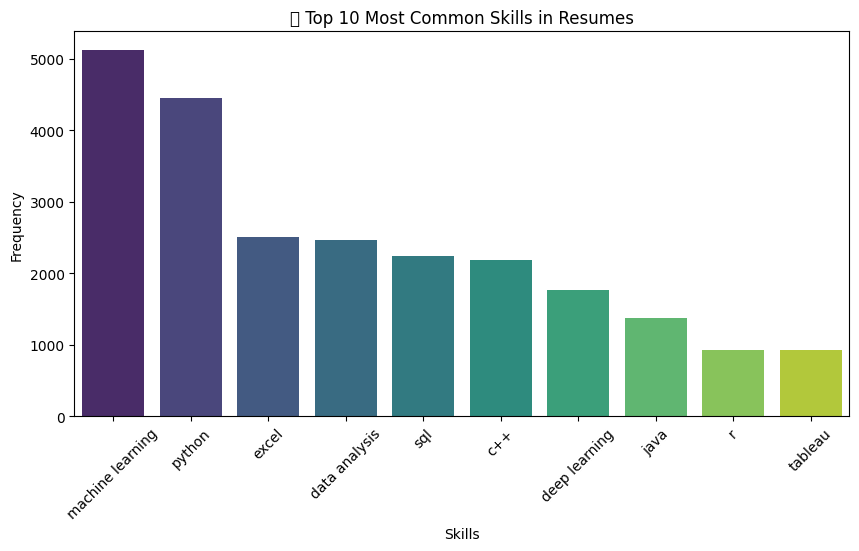

In [143]:
#Top 10 Most Common Skills in Resumes**
all_skills = [skill for skills in df["Extracted_Skills"] for skill in skills]
skill_counts = Counter(all_skills).most_common(10)

skills, counts = zip(*skill_counts)
plt.figure(figsize=(10, 5))
sns.barplot(x=list(skills), y=list(counts), palette="viridis")
plt.xticks(rotation=45)
plt.title("🔹 Top 10 Most Common Skills in Resumes")
plt.xlabel("Skills")
plt.ylabel("Frequency")
plt.show()

<ipython-input-144-4e59b6b119ce>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df["Predicted_Job_Role"], order=df["Predicted_Job_Role"].value_counts().index, palette="coolwarm")
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128313 (\N{SMALL BLUE DIAMOND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


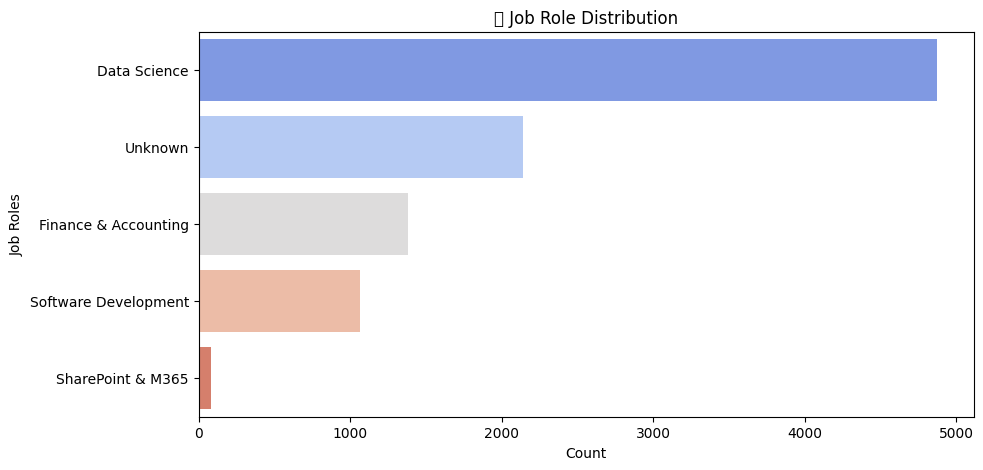

In [144]:
#Job Role Distribution Among Candidates**
plt.figure(figsize=(10, 5))
sns.countplot(y=df["Predicted_Job_Role"], order=df["Predicted_Job_Role"].value_counts().index, palette="coolwarm")
plt.title("🔹 Job Role Distribution")
plt.xlabel("Count")
plt.ylabel("Job Roles")
plt.show()

<ipython-input-145-0c8676808af4>:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(job_counts), y=list(jobs), palette="magma")
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128313 (\N{SMALL BLUE DIAMOND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


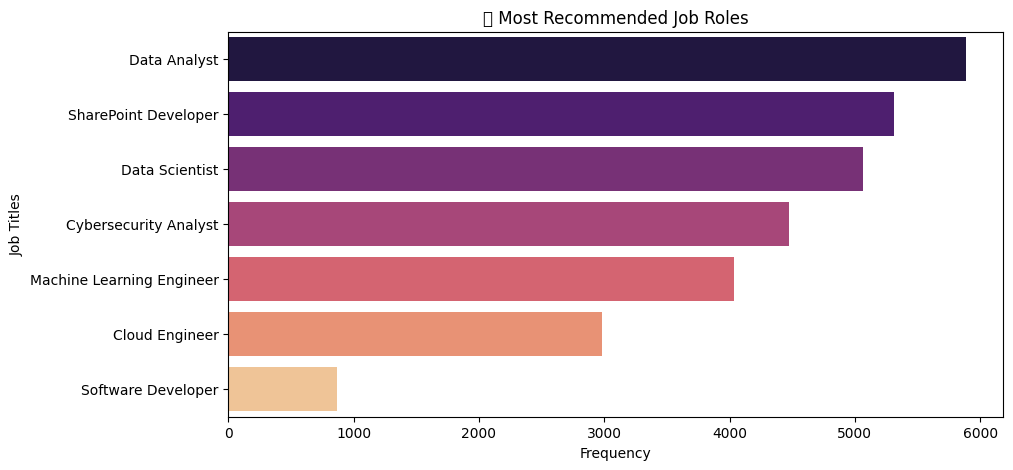

In [145]:
#Most Recommended Job Roles**
recommended_jobs = [job for jobs in df["Recommended_Jobs"].dropna().apply(ast.literal_eval) for job in jobs]
recommended_counts = Counter(recommended_jobs).most_common(10)

jobs, job_counts = zip(*recommended_counts)
plt.figure(figsize=(10, 5))
sns.barplot(x=list(job_counts), y=list(jobs), palette="magma")
plt.title("🔹 Most Recommended Job Roles")
plt.xlabel("Frequency")
plt.ylabel("Job Titles")
plt.show()


<ipython-input-146-707a22af8264>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Predicted_Job_Role", y=df_top_roles["Extracted_Skills"].apply(len), data=df_top_roles, palette="coolwarm")
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128313 (\N{SMALL BLUE DIAMOND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


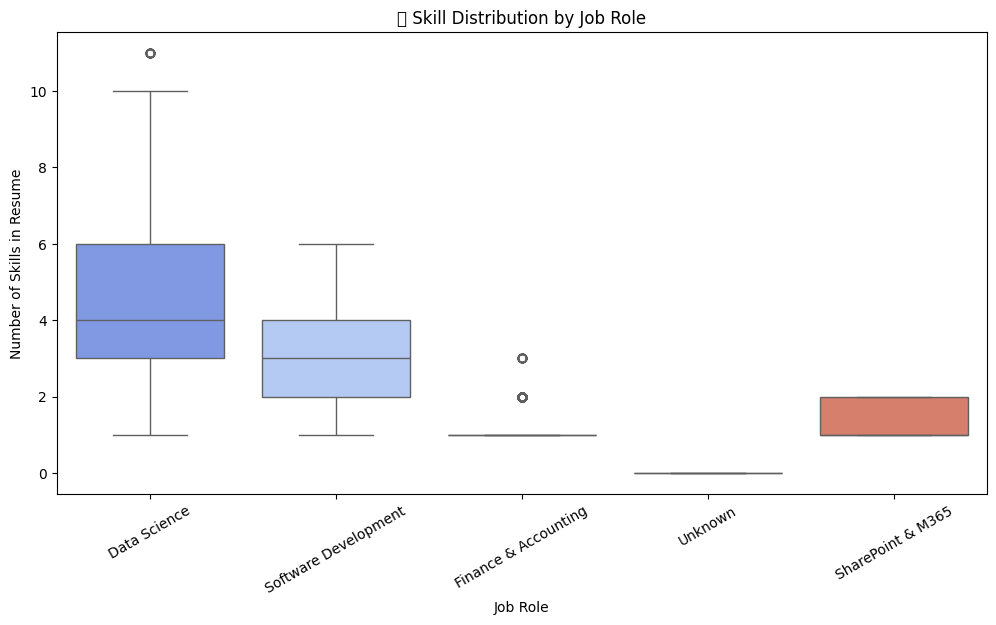

In [146]:
#Skill Distribution by Job Role**
plt.figure(figsize=(12, 6))
top_roles = df["Predicted_Job_Role"].value_counts().index[:5]  # Top 5 job roles
df_top_roles = df[df["Predicted_Job_Role"].isin(top_roles)]
sns.boxplot(x="Predicted_Job_Role", y=df_top_roles["Extracted_Skills"].apply(len), data=df_top_roles, palette="coolwarm")
plt.title("🔹 Skill Distribution by Job Role")
plt.xlabel("Job Role")
plt.ylabel("Number of Skills in Resume")
plt.xticks(rotation=30)
plt.show()

# **Step 8:- Resume Matching Report Generation (Automated PDF Report)**

In [147]:
!pip install fpdf

In [148]:
from fpdf import FPDF
import ast
import pandas as pd

# Load the dataset with recommendations
file_path = "/content/resume_with_recommendations.csv"
df = pd.read_csv(file_path)


In [149]:

# Convert string columns to lists where applicable
df["Extracted_Skills"] = df["Extracted_Skills"].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else [])
df["Recommended_Jobs"] = df["Recommended_Jobs"].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else [])


In [150]:

# Function to generate AI-Powered Resume Report
def generate_resume_report(index):
    candidate = df.iloc[index]

    # Create a PDF instance
    pdf = FPDF()
    pdf.set_auto_page_break(auto=True, margin=15)
    pdf.add_page()

    # Set title font
    pdf.set_font("Arial", style='B', size=16)
    pdf.cell(200, 10, "AI-Powered Resume Analysis Report", ln=True, align="C")
    pdf.ln(10)

    # Set font for content
    pdf.set_font("Arial", size=12)

    # Candidate Information
    pdf.cell(200, 10, f"Candidate: {candidate.get('job_position_name', 'N/A')}", ln=True)
    pdf.cell(200, 10, f"Predicted Job Role: {candidate.get('Predicted_Job_Role', 'N/A')}", ln=True)
    pdf.ln(5)

    # Extracted Skills
    pdf.set_font("Arial", style='B', size=12)
    pdf.cell(200, 10, "Extracted Skills:", ln=True)
    pdf.set_font("Arial", size=12)
    extracted_skills = ", ".join(candidate.get("Extracted_Skills", [])) if isinstance(candidate.get("Extracted_Skills"), list) else "N/A"
    pdf.multi_cell(0, 10, extracted_skills)
    pdf.ln(5)

    # AI Recommended Job Matches
    pdf.set_font("Arial", style='B', size=12)
    pdf.cell(200, 10, "AI Recommended Job Matches:", ln=True)
    pdf.set_font("Arial", size=12)
    job_matches = ", ".join(candidate.get("Job_Matches", [])) if isinstance(candidate.get("Job_Matches"), list) else "N/A"
    pdf.multi_cell(0, 10, job_matches)
    pdf.ln(5)

    # Insights & Recommendations
    pdf.set_font("Arial", style='B', size=12)
    pdf.cell(200, 10, "Insights & Recommendations:", ln=True)
    pdf.set_font("Arial", size=12)
    pdf.multi_cell(0, 10, candidate.get("Insights", "No specific insights available."))

    # Save PDF
    report_filename = f"/content/resume_report_{index}.pdf"
    pdf.output(report_filename)
    print(f"✅ Resume report generated: {report_filename}")

# Generate reports for the first 5 candidates
for i in range(5):
    generate_resume_report(i)

✅ Resume report generated: /content/resume_report_0.pdf
✅ Resume report generated: /content/resume_report_1.pdf
✅ Resume report generated: /content/resume_report_2.pdf
✅ Resume report generated: /content/resume_report_3.pdf
✅ Resume report generated: /content/resume_report_4.pdf


In [151]:
from google.colab import files

# Download all generated reports (assuming 5 reports)
for i in range(5):
    files.download(f"/content/resume_report_{i}.pdf")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# **Step 9:- Job Recommendation & Matching System (AI-Powered Ranking)**

In [157]:
print(resume_df.columns)
print(job_df.columns)

Index(['skills', 'educational_institution_name', 'degree_names',
       'passing_years', 'educational_results', 'result_types',
       'major_field_of_studies', 'professional_company_names', 'company_urls',
       'start_dates', 'end_dates', 'related_skils_in_job', 'positions',
       'locations', 'responsibilities', '﻿job_position_name',
       'educationaL_requirements', 'experiencere_requirement',
       'age_requirement', 'responsibilities.1', 'skills_required',
       'matched_score'],
      dtype='object')
Index(['job_id', 'job_title', 'required_skills'], dtype='object')


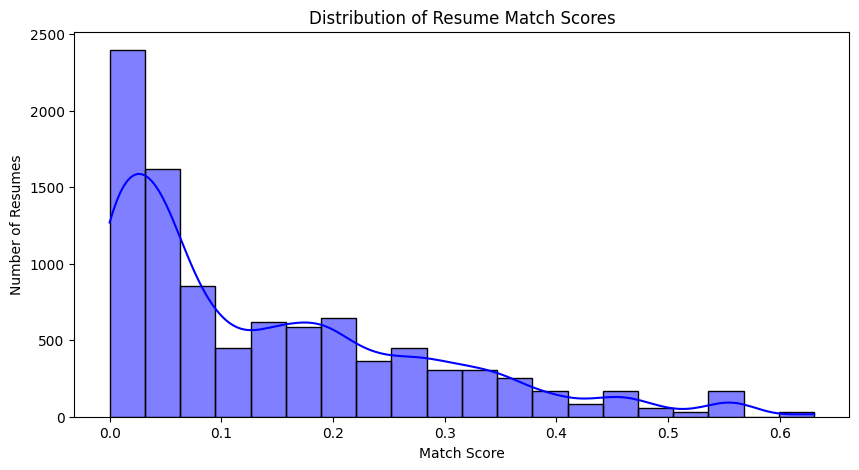

                                                 skills  match_score
3884  ['data analysis', 'data visualization', 'deep ...     0.630915
3566  ['data analysis', 'data visualization', 'deep ...     0.630915
6187  ['data analysis', 'data visualization', 'deep ...     0.630915
2948  ['data analysis', 'data visualization', 'deep ...     0.630915
1917  ['data analysis', 'data visualization', 'deep ...     0.630915


In [158]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
import seaborn as sns

# Load the resume and job datasets
resume_df = pd.read_csv("/content/cleaned_resume_data.csv")  # Update with actual path
job_df = pd.read_csv("/content/job_descriptions.csv")  # Update with actual path

# Ensure necessary columns exist
required_columns_resume = ['skills']
required_columns_job = ['required_skills']

for col in required_columns_resume:
    if col not in resume_df.columns:
        raise KeyError(f"Column '{col}' missing in resume dataset")

for col in required_columns_job:
    if col not in job_df.columns:
        raise KeyError(f"Column '{col}' missing in job dataset")

# Convert skills and job descriptions to strings
resume_df['skills'] = resume_df['skills'].astype(str)
job_df['required_skills'] = job_df['required_skills'].astype(str)

# TF-IDF Vectorization
tfidf = TfidfVectorizer()
skill_matrix = tfidf.fit_transform(resume_df['skills'])
job_matrix = tfidf.transform(job_df['required_skills'])

# Compute cosine similarity
similarity_scores = cosine_similarity(skill_matrix, job_matrix)

# Rank resumes based on job descriptions
resume_df['match_score'] = similarity_scores.max(axis=1)
resume_df = resume_df.sort_values(by='match_score', ascending=False)

# Save the ranked resumes
resume_df.to_csv("/content/ranked_resumes.csv", index=False)

# Visualization of match scores
plt.figure(figsize=(10, 5))
sns.histplot(resume_df['match_score'], bins=20, kde=True, color='blue')
plt.xlabel("Match Score")
plt.ylabel("Number of Resumes")
plt.title("Distribution of Resume Match Scores")
plt.show()

# Display top 5 matched resumes
print(resume_df[['skills', 'match_score']].head())
